### Step 3: Three collinear crack tips with SIF-based edge weights

- Geometry: three tips at (0,0), (1,0), (3,0) forming two crack segments:
  - Segment 0–1: length 1 → half-length a₁ = 0.5
  - Segment 1–2: length 2 → half-length a₂ = 1.0
- Material: isotropic ice, plane strain (E, ν).
- Loads: infinite plate, far-field uniform tension σ∞ (Mode I) and shear τ∞ (Mode II).
  - For examples: σ∞ = 1.0 (dimensionless or in Pa), τ∞ = 0 initially.

**Key approximation:** each segment is treated as an independent infinite-plate crack:
- Mode I SIF:   K_I = σ∞ √(π a)
- Mode II SIF:  K_II = τ∞ √(π a)

Graph construction:
- Nodes 0,1,2 carry:
  - coordinates, orientation θ
  - Recho-style Hamiltonian data (H, eigenvalues, λ_sing)
- Edges (0–1) and (1–2) carry:
  - SIF-based energy release rate G_edge
  - 'weight' = G_edge, used for the fracture graph / MaxCut step.

This keeps the Recho Hamiltonian structure but sets the **edge weights from physical SIF-based G**.


In [21]:
# Cell 1: imports, material constants, loads, and geometry

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ---- Material: isotropic ice, plane strain ----
E_ice = 9.0e9      # Pa (example: 9 GPa)
nu_ice = 0.33

# Effective modulus for plane strain: E' = E / (1 - nu^2)
E_eff_plane_strain = E_ice / (1.0 - nu_ice**2)

# ---- Far-field loads (canonical) ----
# σ∞: remote normal tension (Mode I); τ∞: remote shear (Mode II)
sigma_inf = 1e5   # you can think of this as "1" in non-dimensional units 
tau_inf   = 0.0    # start with pure Mode I; you can play with this later

# ---- Tip positions ----
# 0 -- 1 -- 2 along x-axis at 0, 1, and 3
tip_positions = {
    0: (0.0, 0.0),
    1: (1.0, 0.0),
    2: (3.0, 0.0),
}

# ---- Crack segments (edges) ----
# Each segment: (node_i, node_j, half_length a)
segments = [
    (0, 1, 0.5),  # segment 0-1, length 1 → a = 0.5
    (1, 2, 1.0),  # segment 1-2, length 2 → a = 1.0
]


### Recho-style crack-tip Hamiltonian

We keep a simple Recho-style Hamiltonian per tip to remain consistent with Step 2.2:

- Input: stiffness matrix `C` and local crack orientation `θ`.
- Output: dictionary with:
  - `H`: 2×2 Hamiltonian-like matrix,
  - `H_eigvals`: eigenvalues of `H`,
  - `lambda_sing`: placeholder dominant singular exponent λ (kept for interface).

In this Step 3 version, the **Hamiltonian is not used to compute G**; it is stored alongside the
nodes and can later be combined with SIF-based energies.


In [22]:
# Cell 2: isotropic plane-strain stiffness and Recho-style Hamiltonian helper

def isotropic_plane_strain_stiffness(E: float, nu: float) -> np.ndarray:
    """
    Build the 3x3 plane-strain stiffness matrix in Voigt form (xx, yy, xy).
    """
    lam = E * nu / ((1 + nu) * (1 - 2 * nu))
    mu = E / (2 * (1 + nu))

    C = np.array([
        [lam + 2 * mu, lam,           0.0],
        [lam,           lam + 2 * mu, 0.0],
        [0.0,           0.0,          mu ],
    ])
    return C


C_iso_ice_3x3 = isotropic_plane_strain_stiffness(E_ice, nu_ice)


def crack_tip_hamiltonian_data(C: np.ndarray,
                               theta: float = 0.0) -> dict:
    """
    Toy Recho-style crack-tip Hamiltonian from a (3x3) stiffness matrix C
    and crack orientation theta.

    - Extracts a 2x2 block to mimic the Recho (C22, C24, C42, C44) structure.
    - Adds a simple orientation dependence.
    - Returns eigenvalues and a placeholder 'lambda_sing'.
    """
    # Extract a symmetric 2x2 block from the 3x3 C-matrix (yy / xy components)
    C22 = C[1, 1]
    C24 = C[1, 2]
    C42 = C[2, 1]
    C44 = C[2, 2]

    # Orientation factor (toy): f(theta) ~ 1 + 0.1 cos(2θ)
    f_theta = 1.0 + 0.1 * np.cos(2.0 * theta)

    H = f_theta * np.array([
        [C22, C24],
        [C42, C44],
    ], dtype=float)

    H_eigvals = np.linalg.eigvals(H)

    # Placeholder most singular exponent (kept for compatibility with Step 2.x)
    lambda_sing = 0.5

    return {
        "H": H,
        "H_eigvals": H_eigvals,
        "lambda_sing": lambda_sing,
    }


### Build 3-tip graph nodes with Hamiltonian data

We now build a NetworkX graph with nodes 0, 1, 2:

- `x, y` coordinates,
- `theta` (orientation of the local crack; here all are 0 for collinear x-axis cracks),
- Recho-style Hamiltonian data from `crack_tip_hamiltonian_data`.

Edges are added later once we compute SIF-based energies.


In [23]:
# Cell 3: create a 3-node graph with Hamiltonian data

def build_three_tip_graph_with_H(C: np.ndarray,
                                 tip_positions: dict,
                                 theta: float = 0.0) -> nx.Graph:
    """
    Build a graph with nodes at the given tip positions, each carrying
    Recho-style Hamiltonian data.
    """
    G = nx.Graph()

    for j, (x, y) in tip_positions.items():
        tip_data = crack_tip_hamiltonian_data(C=C, theta=theta)

        G.add_node(
            j,
            id=j,
            x=x,
            y=y,
            theta=theta,
            **tip_data,  # H, H_eigvals, lambda_sing
        )

    return G


G_three = build_three_tip_graph_with_H(C_iso_ice_3x3, tip_positions, theta=0.0)

print("Nodes with Hamiltonian data created:")
for n, d in G_three.nodes(data=True):
    print(f"  Node {n}: (x={d['x']}, y={d['y']}), theta={d['theta']}, lambda_sing={d['lambda_sing']}")


Nodes with Hamiltonian data created:
  Node 0: (x=0.0, y=0.0), theta=0.0, lambda_sing=0.5
  Node 1: (x=1.0, y=0.0), theta=0.0, lambda_sing=0.5
  Node 2: (x=3.0, y=0.0), theta=0.0, lambda_sing=0.5


### SIF and energy release formulas (independent-crack approximation)

For each straight crack segment of half-length `a`:

- Mode I SIF (infinite plate, remote tension σ∞):

  \[
  K_I = \sigma_\infty \sqrt{\pi a}
  \]

- Mode II SIF (approximate, infinite plate, remote shear τ∞):

  \[
  K_{II} = \tau_\infty \sqrt{\pi a}
  \]

Under plane strain, the energy release rate is:

\[
G = \frac{1}{E'} (K_I^2 + K_{II}^2), \quad E' = \frac{E}{1 - \nu^2}.
\]

We use this to define an **edge energy** per segment.


In [24]:
# Cell 4: SIF and energy release helpers

def sif_for_straight_crack(a: float,
                           sigma_inf: float,
                           tau_inf: float) -> tuple[float, float]:
    """
    Stress intensity factors for a straight crack of half-length a in an infinite plate,
    under remote uniform tension sigma_inf (Mode I) and shear tau_inf (Mode II).

        K_I  = sigma_inf * sqrt(pi * a)
        K_II = tau_inf   * sqrt(pi * a)

    This treats each crack independently (no interaction).
    """
    factor = np.sqrt(np.pi * a)
    K_I = sigma_inf * factor
    K_II = tau_inf * factor
    return K_I, K_II


def energy_release_plane_strain(K_I: float,
                                K_II: float,
                                E_eff: float) -> float:
    """
    Energy release rate G under plane strain:

        G = (K_I^2 + K_II^2) / E_eff

    where E_eff = E / (1 - nu^2).
    """
    return (K_I**2 + K_II**2) / E_eff


### Add edges and assign SIF-based energy-release weights

For each segment `(i, j, a)`:

1. Compute `K_I, K_II = sif_for_straight_crack(a, sigma_inf, tau_inf)`.
2. Compute `G_edge = energy_release_plane_strain(K_I, K_II, E_eff_plane_strain)`.
3. Add an edge `(i, j)` to the graph with attributes:
   - `"a"`: half-length,
   - `"K_I"`, `"K_II"`,
   - `"G_edge"`: SIF-based energy,
   - `"weight"`: equal to `G_edge` (for use in graph algorithms / MaxCut).


In [25]:
# Cell 5: build edges with SIF-based energy-release weights

def add_sif_edges_to_graph(G: nx.Graph,
                           segments: list[tuple[int, int, float]],
                           sigma_inf: float,
                           tau_inf: float,
                           E_eff: float) -> None:
    """
    For each segment (i, j, a) in 'segments', compute SIFs and energy release rate,
    and add an edge (i, j) to G with these as attributes.
    """
    for i, j, a in segments:
        K_I, K_II = sif_for_straight_crack(a, sigma_inf, tau_inf)
        G_edge = energy_release_plane_strain(K_I, K_II, E_eff)

        G.add_edge(
            i,
            j,
            a=a,
            K_I=K_I,
            K_II=K_II,
            G_edge=G_edge,
            weight=G_edge,
        )


add_sif_edges_to_graph(G_three, segments, sigma_inf, tau_inf, E_eff_plane_strain)

print("Edges with SIF-based energy-release weights:")
for u, v, d in G_three.edges(data=True):
    print(f"  Edge ({u}-{v}): a={d['a']}, K_I={d['K_I']:.4g}, K_II={d['K_II']:.4g}, G_edge={d['G_edge']:.4g}")


Edges with SIF-based energy-release weights:
  Edge (0-1): a=0.5, K_I=1.253e+05, K_II=0, G_edge=1.555
  Edge (1-2): a=1.0, K_I=1.772e+05, K_II=0, G_edge=3.111


### Adjacency matrix and graph visualisation

We now:

1. Extract the **weighted adjacency matrix** (using `weight = G_edge`).
2. Plot the 3-node graph with:
   - physical coordinates (0,0), (1,0), (3,0),
   - edge labels showing `G_edge`.

This gives you a complete SIF-based Step 3 graph ready to feed into the next
Hamiltonian/MaxCut layers.


Weighted adjacency matrix (nodes in order: [0, 1, 2] ):
[[0.         1.5552629  0.        ]
 [1.5552629  0.         3.11052579]
 [0.         3.11052579 0.        ]]


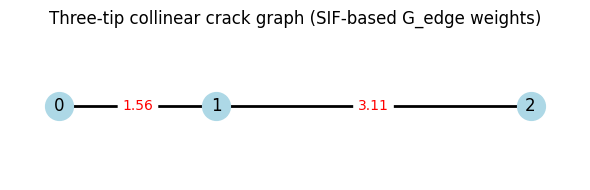

In [26]:
# Cell 6: adjacency matrix and plot

def get_weighted_adjacency(G: nx.Graph) -> np.ndarray:
    """
    Return the weighted adjacency matrix using the 'weight' attribute.
    Nodes are assumed to be labeled 0,1,2 in ascending order.
    """
    nodes = sorted(G.nodes())
    A = nx.to_numpy_array(G, nodelist=nodes, weight="weight", dtype=float)
    return A, nodes


def plot_three_tip_graph(G: nx.Graph, title: str | None = None) -> None:
    """
    Plot the three-tip collinear graph using physical coordinates, with
    edges labeled by G_edge.
    """
    pos = {n: (d["x"], d["y"]) for n, d in G.nodes(data=True)}

    plt.figure(figsize=(6, 2))

    nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=400)
    nx.draw_networkx_labels(G, pos, font_size=12)
    nx.draw_networkx_edges(G, pos, width=2)

    edge_labels = {(u, v): f"{d['G_edge']:.3g}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                 font_size=10, font_color="red")

    if title is None:
        title = "Three-tip collinear crack graph (SIF-based G_edge weights)"
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# ---- Run and display adjacency matrix + plot ----
A, node_order = get_weighted_adjacency(G_three)

print("Weighted adjacency matrix (nodes in order:", node_order, "):")
print(A)

plot_three_tip_graph(G_three)

In [7]:
# Extra Cell: compute lambda-based relative energy on each edge

def mode_strength_from_H_eigs(node_data: dict) -> float:
    """
    Compute a scalar 'mode strength' from the eigenvalues of the node Hamiltonian H:

        s = sum_j |μ_j|

    where μ_j are the eigenvalues of H (stored in 'H_eigvals').
    """
    eigvals = node_data["H_eigvals"]
    return float(np.sum(np.abs(eigvals)))


def relative_energy_release_from_nodes(node_data_1: dict,
                                       node_data_2: dict,
                                       E_eff: float) -> float:
    """
    Relative energy-release-like quantity for an edge connecting two crack-tip nodes,
    based on Hamiltonian eigenvalues:

        s_i = sum_j |μ_j|
        G_i,rel   = s_i^2
        G_edge,λ  = 0.5 * (G_i,rel + G_j,rel) / E_eff
    """
    s1 = mode_strength_from_H_eigs(node_data_1)
    s2 = mode_strength_from_H_eigs(node_data_2)

    G1_rel = s1 ** 2
    G2_rel = s2 ** 2

    G_edge_rel = 0.5 * (G1_rel + G2_rel) / E_eff
    return float(G_edge_rel)


# Attach lambda-based energy to each edge of G_three
for u, v in G_three.edges():
    node_u = G_three.nodes[u]
    node_v = G_three.nodes[v]

    G_rel_lambda = relative_energy_release_from_nodes(
        node_u, node_v, E_eff=E_eff_plane_strain
    )

    G_three[u][v]["G_rel_lambda"] = G_rel_lambda
    G_three[u][v]["weight_lambda"] = G_rel_lambda  # alternative weight

print("Edges with both SIF-based and lambda-based energies:")
for u, v, d in G_three.edges(data=True):
    print(
        f"  Edge ({u}-{v}): "
        f"G_edge (SIF) = {d['G_edge']:.4g}, "
        f"G_rel_lambda = {d['G_rel_lambda']:.4g}"
    )

# Optional: adjacency matrix using lambda-based weights
A_lambda, node_order_lambda = nx.to_numpy_array(
    G_three, nodelist=sorted(G_three.nodes()), weight="weight_lambda", dtype=float
), sorted(G_three.nodes())

print("\nWeighted adjacency matrix using lambda-based weights (nodes in order:", node_order_lambda, "):")
print(A_lambda)


Edges with both SIF-based and lambda-based energies:
  Edge (0-1): G_edge (SIF) = 1.555e-10, G_rel_lambda = 3.349e+10
  Edge (1-2): G_edge (SIF) = 3.111e-10, G_rel_lambda = 3.349e+10

Weighted adjacency matrix using lambda-based weights (nodes in order: [0, 1, 2] ):
[[0.00000000e+00 3.34851138e+10 0.00000000e+00]
 [3.34851138e+10 0.00000000e+00 3.34851138e+10]
 [0.00000000e+00 3.34851138e+10 0.00000000e+00]]


This is not so good since there's no distance dependence here.